In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("height-weight.csv")
df.head()

,weight,height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

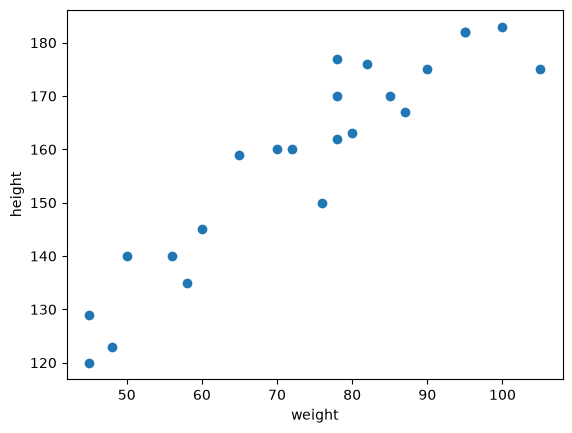

In [3]:
plt.scatter(df['weight'], df['height'])
plt.xlabel('weight')
plt.ylabel('height')

In [13]:
## divide our dataset into independent and dependent edatures
X=df[['weight']] ##independent feature
y=df['height'] ##dependent feature


In [15]:
#train test split
from sklearn.model_selection import train_test_split


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [17]:
X_train. shape, X_test. shape, y_train. shape, y_test. shape

((18, 1), (5, 1), (18,), (5,))

In [19]:
#Standardize the dataset (independent train data)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

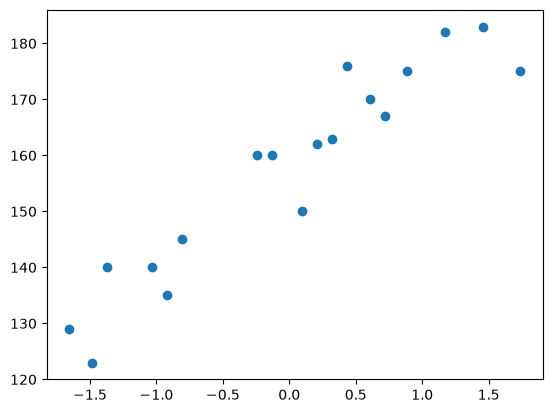

In [20]:
plt.scatter(X_train, y_train)

In [25]:
#training the simple lin reg model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)
print(f"the slope is : {regressor.coef_}\n and the intercept is : {regressor.intercept_}")

the slope is : [17.03440872]
 and the intercept is : 157.5


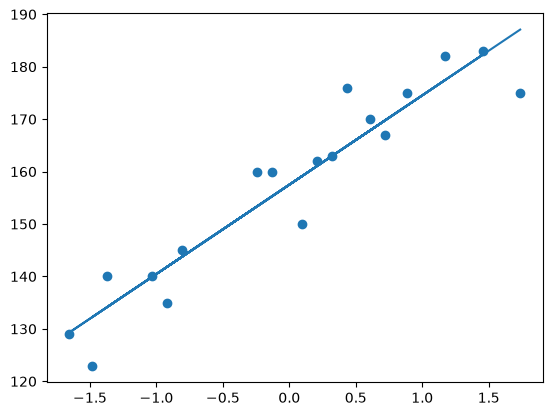

In [28]:
#best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train))

In [30]:
# prediction for test data
y_pred_test = regressor.predict(X_test)
y_pred_test, y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: height, dtype: int64)

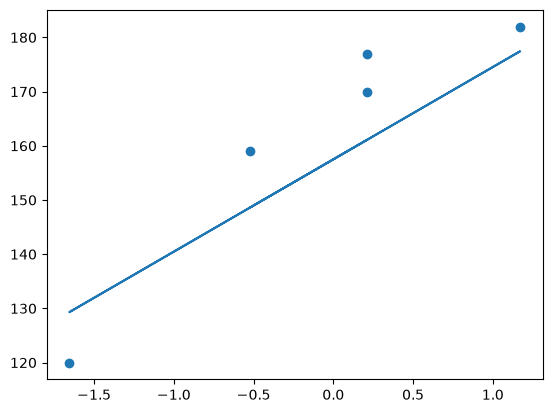

In [31]:
#best fit line
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_test)

In [32]:
#performance metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error

mse=mean_squared_error(y_test, y_pred_test)
mae=mean_absolute_error(y_test, y_pred_test)
rmse=np. sqrt(mse)
print(mse)
print(mae)
print(rmse)


109.77592599051664
9.822657814519232
10.477400726827081


In [34]:
# r2 and adj r2
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_test) 
print("Accuracy :", score)
adj_r2 = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test. shape[1]-1)
print(adj_r2)

Accuracy : 0.776986986042344
0.7026493147231252
